# Toy charging-station example (presentation)

Edit the **station** and **EV list** below, run the episode, then use the metric tables and figures in slides.

Arrivals are **exact** (not Poisson). The helpers live under `toy_demo/` and call the existing env, metrics, and plot modules.

In [42]:
from pathlib import Path
import sys

# Repo root = parent of toy_demo/ (works even if the kernel cwd is toy_demo/)
ROOT = Path.cwd()
if ROOT.name == "toy_demo":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt

from policy.queue.fifo import FIFOQueuePolicy
from policy.queue.closest_power_match import ClosestPowerMatchQueuePolicy
from metrics.validate import validate_episode, report_queueing_laws
from visualization.pile_power import plot_pile_nozzle_power
from visualization.ev_curves import plot_ev_theory_vs_sim

from toy_demo.scenario import ToyEVSpec, ToyStationSpec, default_four_ev_specs
from toy_demo.runner import run_toy_episode, metrics_table, finished_ev_table

print("ROOT =", ROOT)

ROOT = d:\OneDrive - University of Toronto\Uni\Ph.D\Thesis\Chapter 2 - Queueing\Python Codes


## 1. Station layout

Change pile count, nozzles per pile, bricks, and brick power (kW).

In [43]:
station = ToyStationSpec(
    n_piles=2,
    n_nozzles=2,
    n_bricks=4,
    p_brick=25.0,
    queue_capacity=10,
)
station

ToyStationSpec(n_piles=2, n_nozzles=2, n_bricks=4, p_brick=25.0, queue_capacity=10, mean_interarrival=60.0)

## 2. EVs and arrival times

Each row is one EV: `arrival_time` (min), `battery_kwh`, `s_i`, `s_f`.
Start from the default four-EV cast, or replace the list entirely.

In [56]:
#ev_specs = default_four_ev_specs()

# --- e.g. ---
ev_specs = [
    ToyEVSpec(id=0, arrival_time=0.0, battery_kwh=75.0, s_i=0.20, s_f=0.80),
    ToyEVSpec(id=1, arrival_time=0.0, battery_kwh=150.0, s_i=0.2, s_f=0.8),
    ToyEVSpec(id=2, arrival_time=0.0, battery_kwh=150.0, s_i=0.2, s_f=0.8),
    ToyEVSpec(id=3, arrival_time=0.0, battery_kwh=75.0, s_i=0.2, s_f=0.80),
]

for s in ev_specs:
    print(
        f"EV {s.id}: arr={s.arrival_time:.1f} min, "
        f"C_b={s.battery_kwh:.0f} kWh, s_i={s.s_i:.2f}, s_f={s.s_f:.2f}"
    )

EV 0: arr=0.0 min, C_b=75 kWh, s_i=0.20, s_f=0.80
EV 1: arr=0.0 min, C_b=150 kWh, s_i=0.20, s_f=0.80
EV 2: arr=0.0 min, C_b=150 kWh, s_i=0.20, s_f=0.80
EV 3: arr=0.0 min, C_b=75 kWh, s_i=0.20, s_f=0.80


## 3. Policy and horizon

`horizon` is when the clock stops (`SIM_OVER`). If anyone is still charging at the end, increase it.

In [60]:
policy = FIFOQueuePolicy()
# policy = ClosestPowerMatchQueuePolicy()

horizon = 140.0  # minutes; or None → last arrival + 90

env = run_toy_episode(
    station,
    ev_specs,
    policy=policy,
    horizon=horizon,
    seed=0,
    policy_seed=1,
)
print(
    f"Done at t={env.engine.current_time:.2f} min | "
    f"arrived={len(env.engine.metrics.arrived_evs)}, "
    f"finished={len(env.engine.metrics.finished_evs)}, "
    f"dropped={len(env.engine.metrics.dropped_evs)}"
)

Done at t=140.00 min | arrived=4, finished=4, dropped=0


## 4. Metrics

In [61]:
summary = metrics_table(env)
display(summary)

per_ev = finished_ev_table(env)
display(per_ev)

validate_episode(env, verbose=True, raise_on_fail=False)
report_queueing_laws(env, verbose=True)

,value
metric,
sim time (min),140.000000
arrived,4.000000
finished,4.000000
dropped,0.000000
still queued,0.000000
still plugged,0.000000
total energy (kWh),270.000000
average L,2.327205
average Q,0.000000


,ev_id,arrival,service_start,departure,wait,service,s_i,s_f,s_end,battery_kwh,pile,nozzle,energy_kwh
0,0,0.0,0.0,54.90437,0.0,54.90437,0.2,0.8,0.8,75.0,0,0,45.0
1,1,0.0,0.0,108.00000,0.0,108.00000,0.2,0.8,0.8,150.0,1,1,90.0
2,2,0.0,0.0,108.00000,0.0,108.00000,0.2,0.8,0.8,150.0,1,0,90.0
3,3,0.0,0.0,54.90437,0.0,54.90437,0.2,0.8,0.8,75.0,0,1,45.0



=== Episode validation ===
  arrived=4, finished=4, dropped=0, queued=0, plugged=0
  [PASS] Finished: s_current ~= s_f: ok for all finished EVs
  [PASS] Finished: energy_received ~= c_b*(s_f-s_i)/HR2MIN: ok for all finished EVs
  [PASS] Finished: energy_received ~= energy_received_2: ok for all finished EVs
  [PASS] Finished: departure_time >= service_start_time >= arrival_time: ok for all finished EVs
  [PASS] Finished: pile_tracker / nozzle_id_tracker set: ok for all finished EVs
  [PASS] Finished: p_act <= p_req in charge_trace: ok for all finished EVs
  [PASS] Dropped: never got service_start_time / empty charge_trace: ok for all dropped EVs
  [PASS] arrived = finished + dropped + queued + plugged: 4 vs 4+0+0+0=4

=== Queueing laws ===
  T=140.0 min, finished=4, c=4 servers
  lambda_eff=0.028571 /min
  E[W]=81.4522 min, E[W_q]=0.0000 min, E[S]=81.4522 min
  Little L = lambda_eff * W :  theory=2.3272  sim=2.3272  |diff|=0.0000
  Little Q = lambda_eff * W_q:  theory=0.0000  sim=0.00

{'T': 140.0,
 'n_finished': 4.0,
 'lambda_eff': 0.02857142857142857,
 'W': 81.45218486942137,
 'W_q': 0.0,
 'W_q_max': 0.0,
 'S': 81.45218486942137,
 'mu': 0.012277141510729667,
 'c': 4.0,
 'L_sim': 2.3272052819834683,
 'L_theory': 2.327205281983468,
 'Q_sim': 0.0,
 'Q_theory': 0.0,
 'rho_sim': 0.581801320495867,
 'rho_theory': 0.5818013204958669,
 'E_total': 270.0,
 'E_avg': 67.5,
 'c_s2': 0.14164160178872598}

## 5. Visuals

Pile power vs time (one figure per pile), then theory-vs-sim curves for selected EVs.

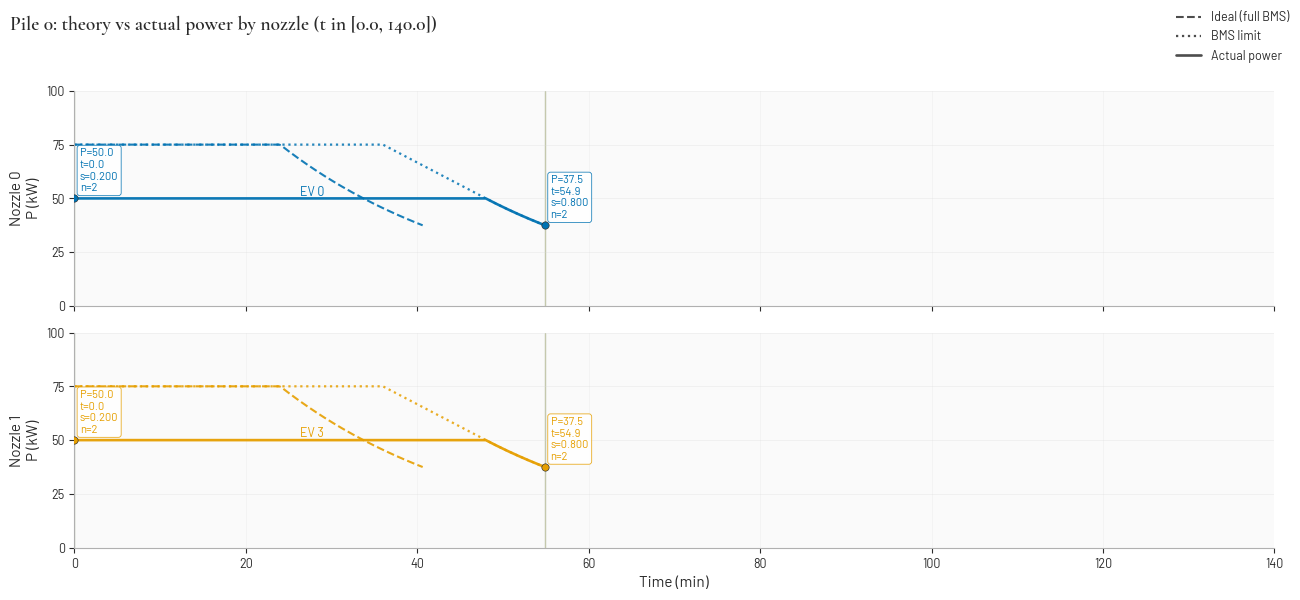

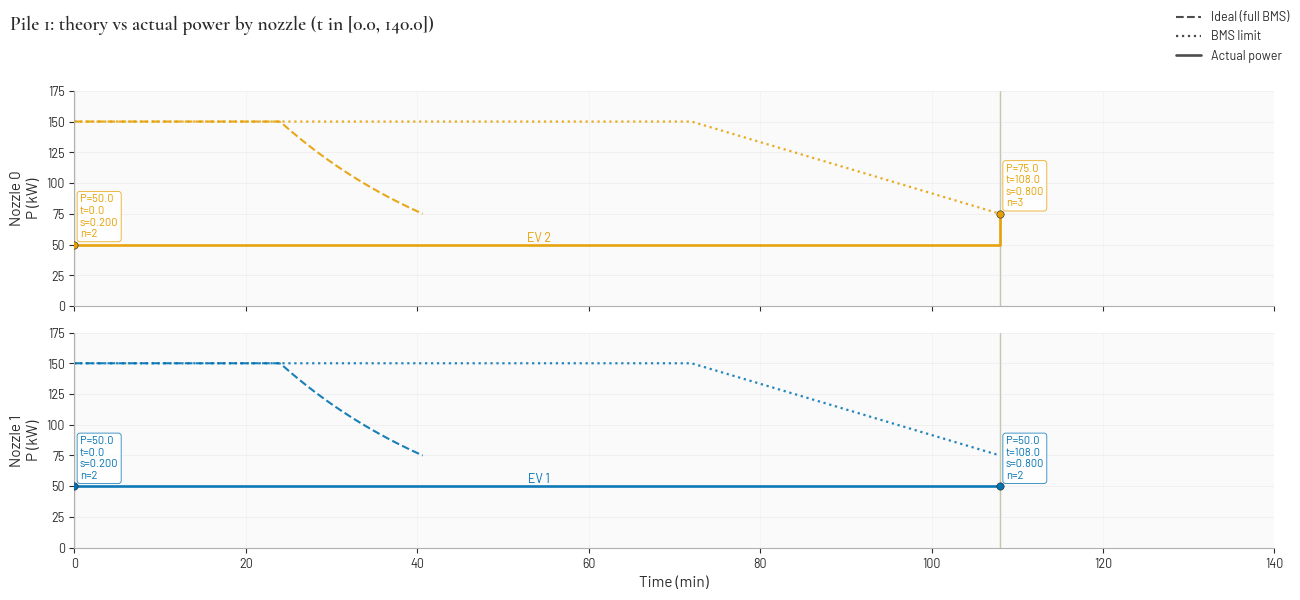

In [62]:
t_end = float(env.engine.current_time)
pile_figs = []
for pile_id in range(station.n_piles):
    fig = plot_pile_nozzle_power(
        env,
        pile_id=pile_id,
        t_start=0.0,
        t_end=t_end,
        show_theory=True,
        show_sim_bms=True,
        show_actual=True,
        show_charge_change_lines=False,
        show_charge_change_vlines=False,
        show_event_lines=True,
        show_trace_labels=True,
    )
    pile_figs.append(fig)
    display(fig)

Plotting EV 0 (pile 0, nozzle 0), charts=['P-S', 'T-S', 'P-T'], trace_len=3
Plotting EV 1 (pile 1, nozzle 0), charts=['P-S', 'T-S', 'P-T'], trace_len=6
Plotting EV 2 (pile 1, nozzle 1), charts=['P-S', 'T-S', 'P-T'], trace_len=4
Plotting EV 3 (pile 0, nozzle 1), charts=['P-S', 'T-S', 'P-T'], trace_len=3


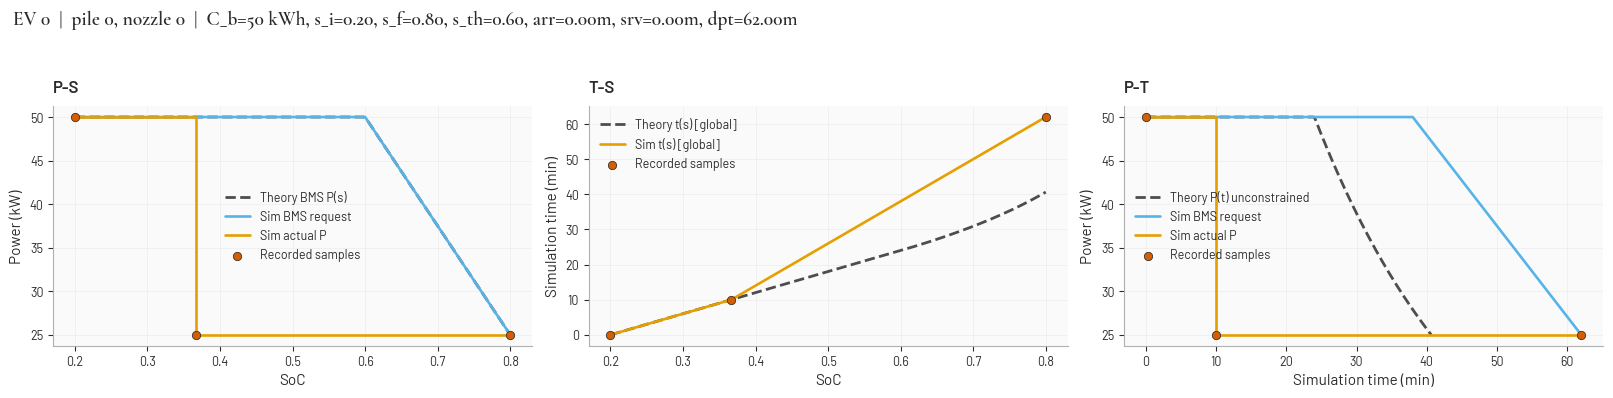

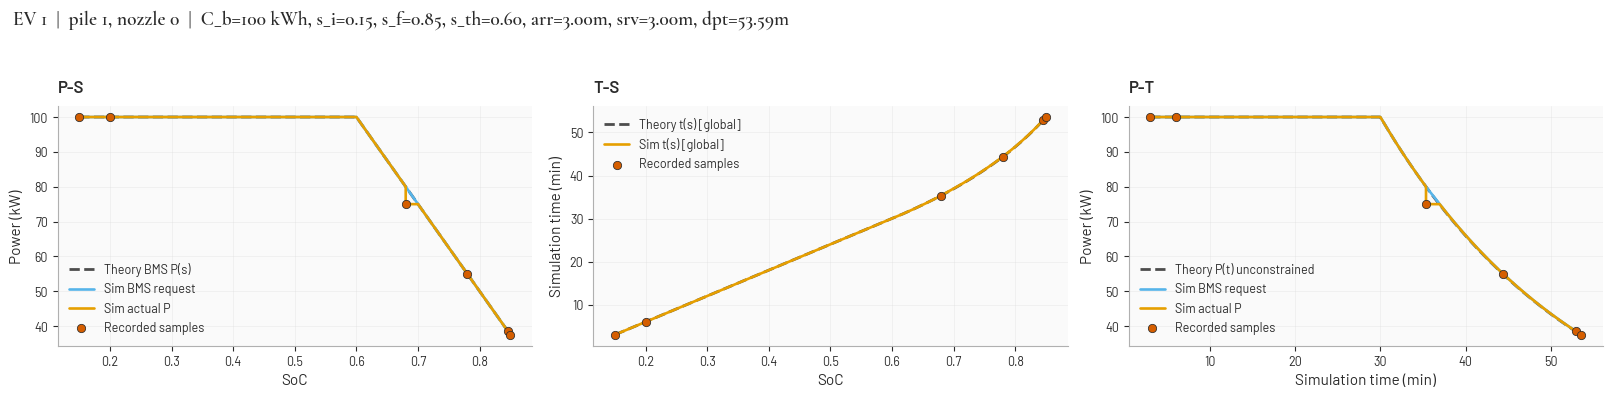

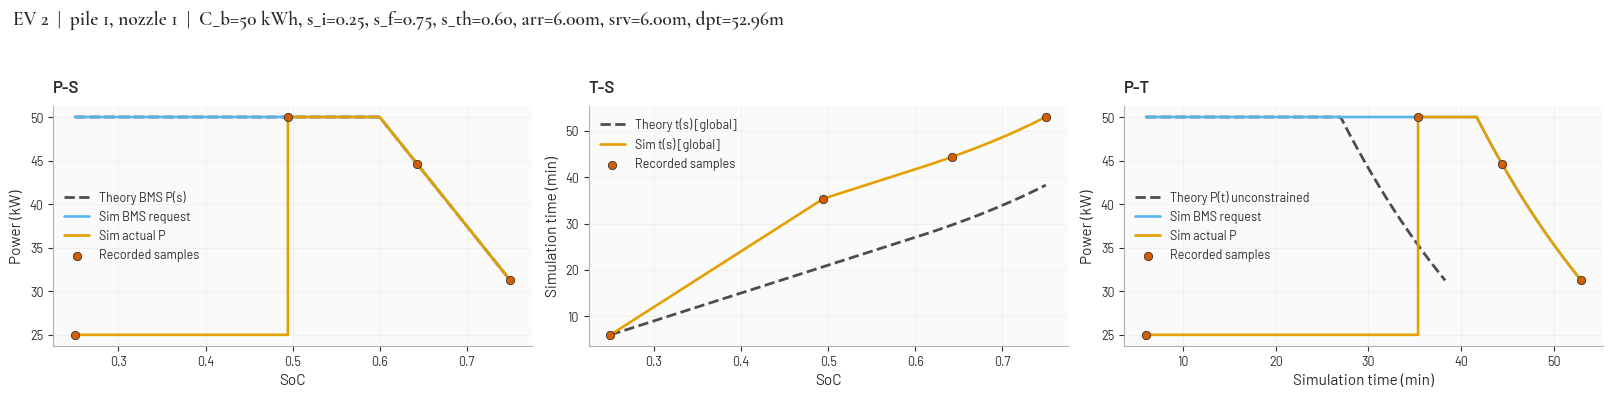

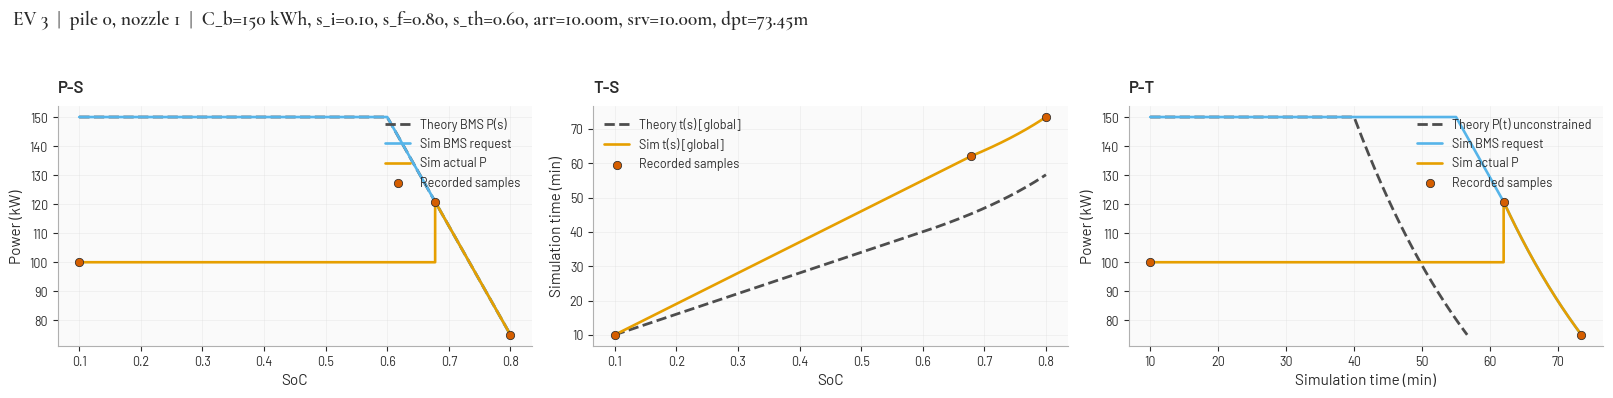

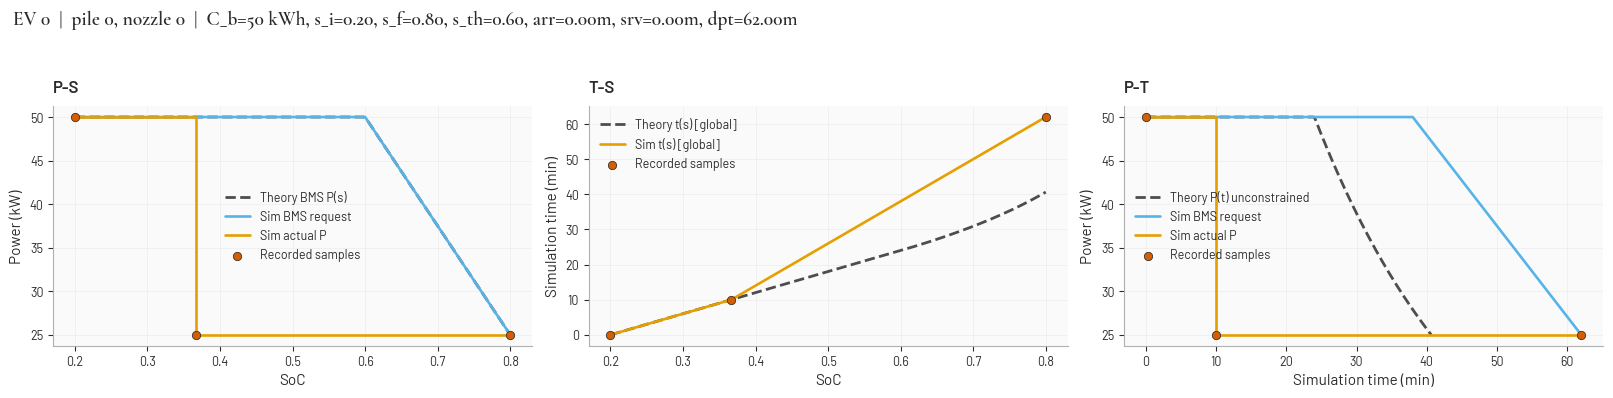

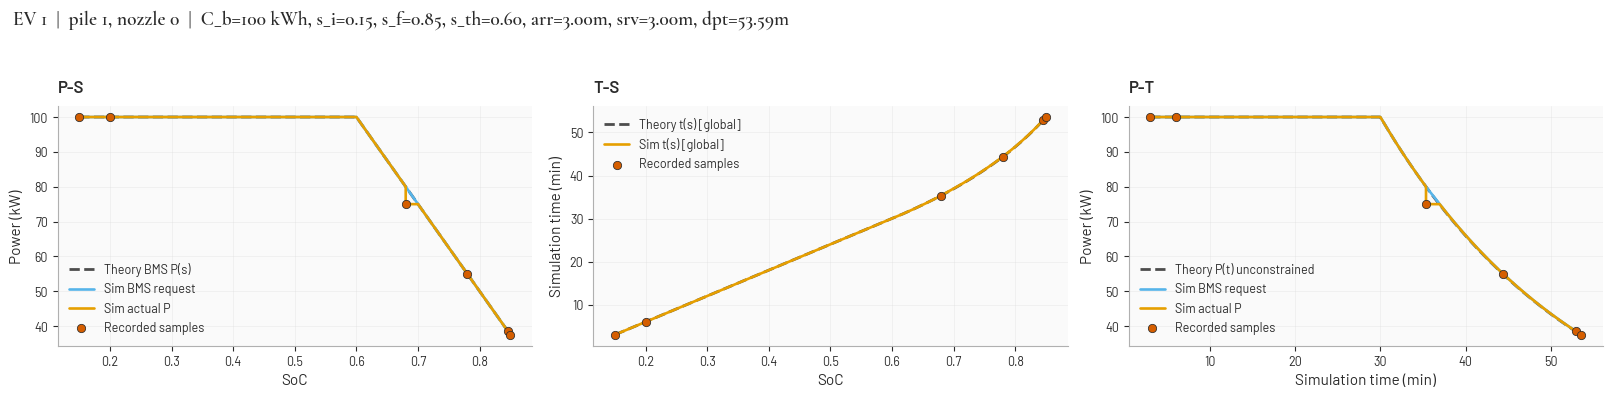

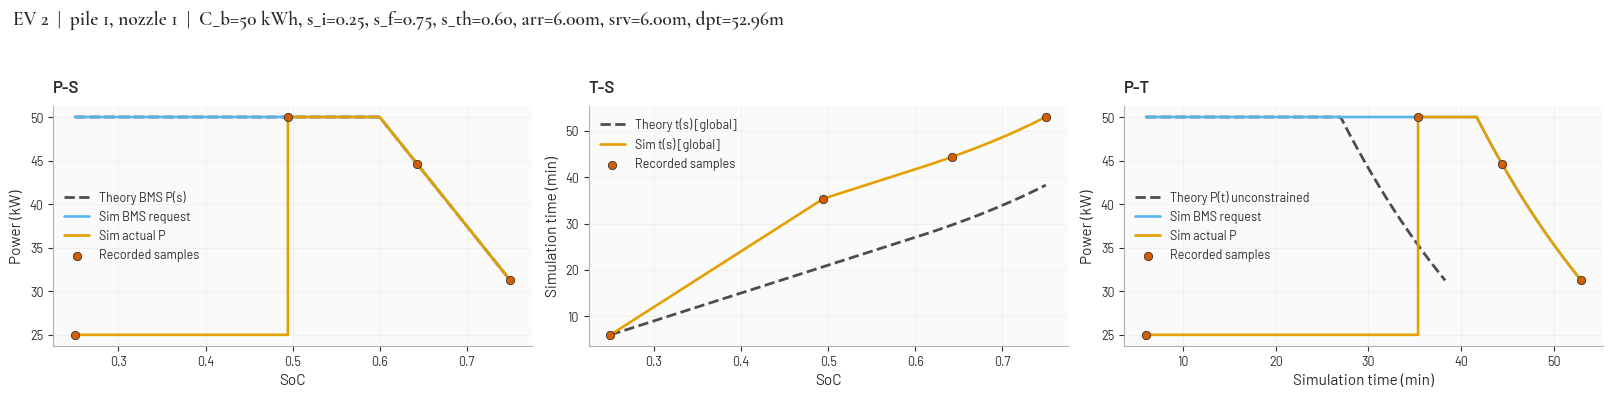

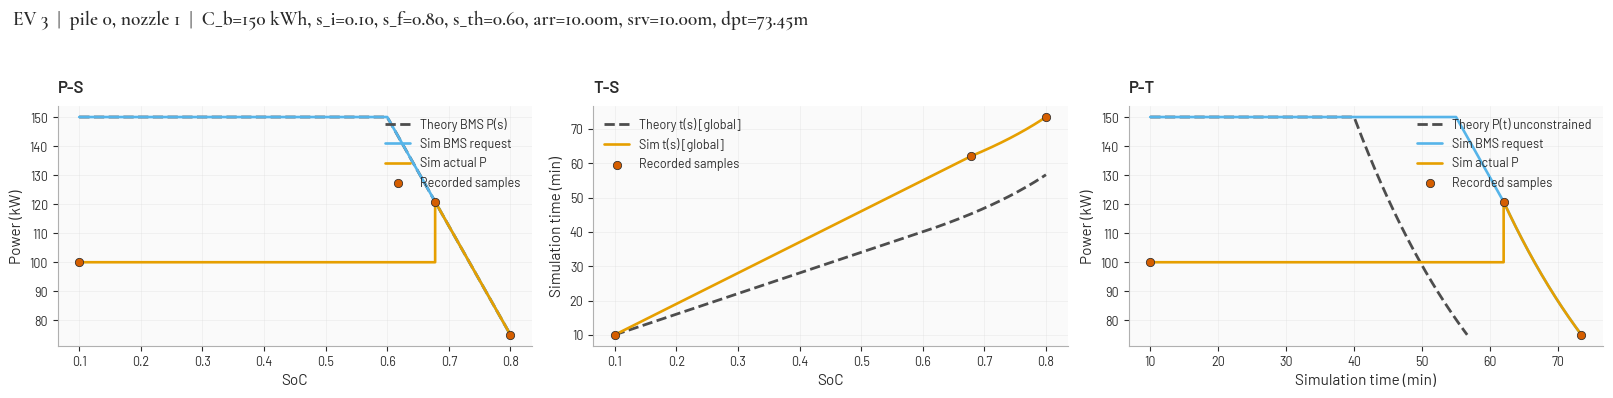

In [7]:
ev_ids = [s.id for s in ev_specs]
ev_figs = plot_ev_theory_vs_sim(
    env,
    ev_ids=ev_ids,
    charts=["P-S", "T-S", "P-T"],
    show_theory=True,
    show_sim_bms=True,
    show_sim_actual=True,
    show_recorded_samples=True,
)
for fig in ev_figs:
    display(fig)

## 6. Optional: save figures for the deck

Uncomment to write PNGs under `toy_demo/output/`.

In [ ]:
# out = ROOT / "toy_demo" / "output"
# out.mkdir(parents=True, exist_ok=True)
# for i, fig in enumerate(pile_figs):
#     fig.savefig(out / f"pile_{i}.png", dpi=200, bbox_inches="tight")
# for ev_id, fig in zip(ev_ids, ev_figs):
#     fig.savefig(out / f"ev_{ev_id}.png", dpi=200, bbox_inches="tight")
# summary.to_csv(out / "summary_metrics.csv")
# per_ev.to_csv(out / "finished_evs.csv", index=False)
# print("Saved to", out)